In [11]:
import zipfile

zip_path = "/content/dataset.v11i.yolov8.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

In [12]:
!ls /content

dataset.v11i.yolov8.zip  README.dataset.txt   sample_data  train
data.yaml		 README.roboflow.txt  test	   valid


In [13]:
!pip install ultralytics

In [14]:
!cat /content/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['Apple', 'Banana', 'Cup', 'Glass', 'Medicine', 'Orange', 'Remote', 'Water Bottle']

roboflow:
  workspace: voiceautomatedhelpinghand-fmskv
  project: household-objects-detection-ggloy
  version: 11
  license: CC BY 4.0
  url: https://universe.roboflow.com/voiceautomatedhelpinghand-fmskv/household-objects-detection-ggloy/dataset/11

In [16]:
from pathlib import Path

yaml_path = Path("/content/data.yaml")
print(yaml_path.read_text())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['Apple', 'Banana', 'Cup', 'Glass', 'Medicine', 'Orange', 'Remote', 'Water Bottle']

roboflow:
  workspace: voiceautomatedhelpinghand-fmskv
  project: household-objects-detection-ggloy
  version: 11
  license: CC BY 4.0
  url: https://universe.roboflow.com/voiceautomatedhelpinghand-fmskv/household-objects-detection-ggloy/dataset/11


In [18]:
!cat /content/data.yaml

train: train/images
val: valid/images
test: test/images

nc: 8
names:
  - Apple
  - Banana
  - Cup
  - Glass
  - Medicine
  - Orange
  - Remote
  - Water Bottle


In [20]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    imgsz=640,
    epochs=50,
    patience=10,
    batch=16,
    augment=True,
    project="/content/runs",
    name="household_objects"
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=household_objects-2, nbs=64, nms=False, opset=None, optimize=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c7102b7500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

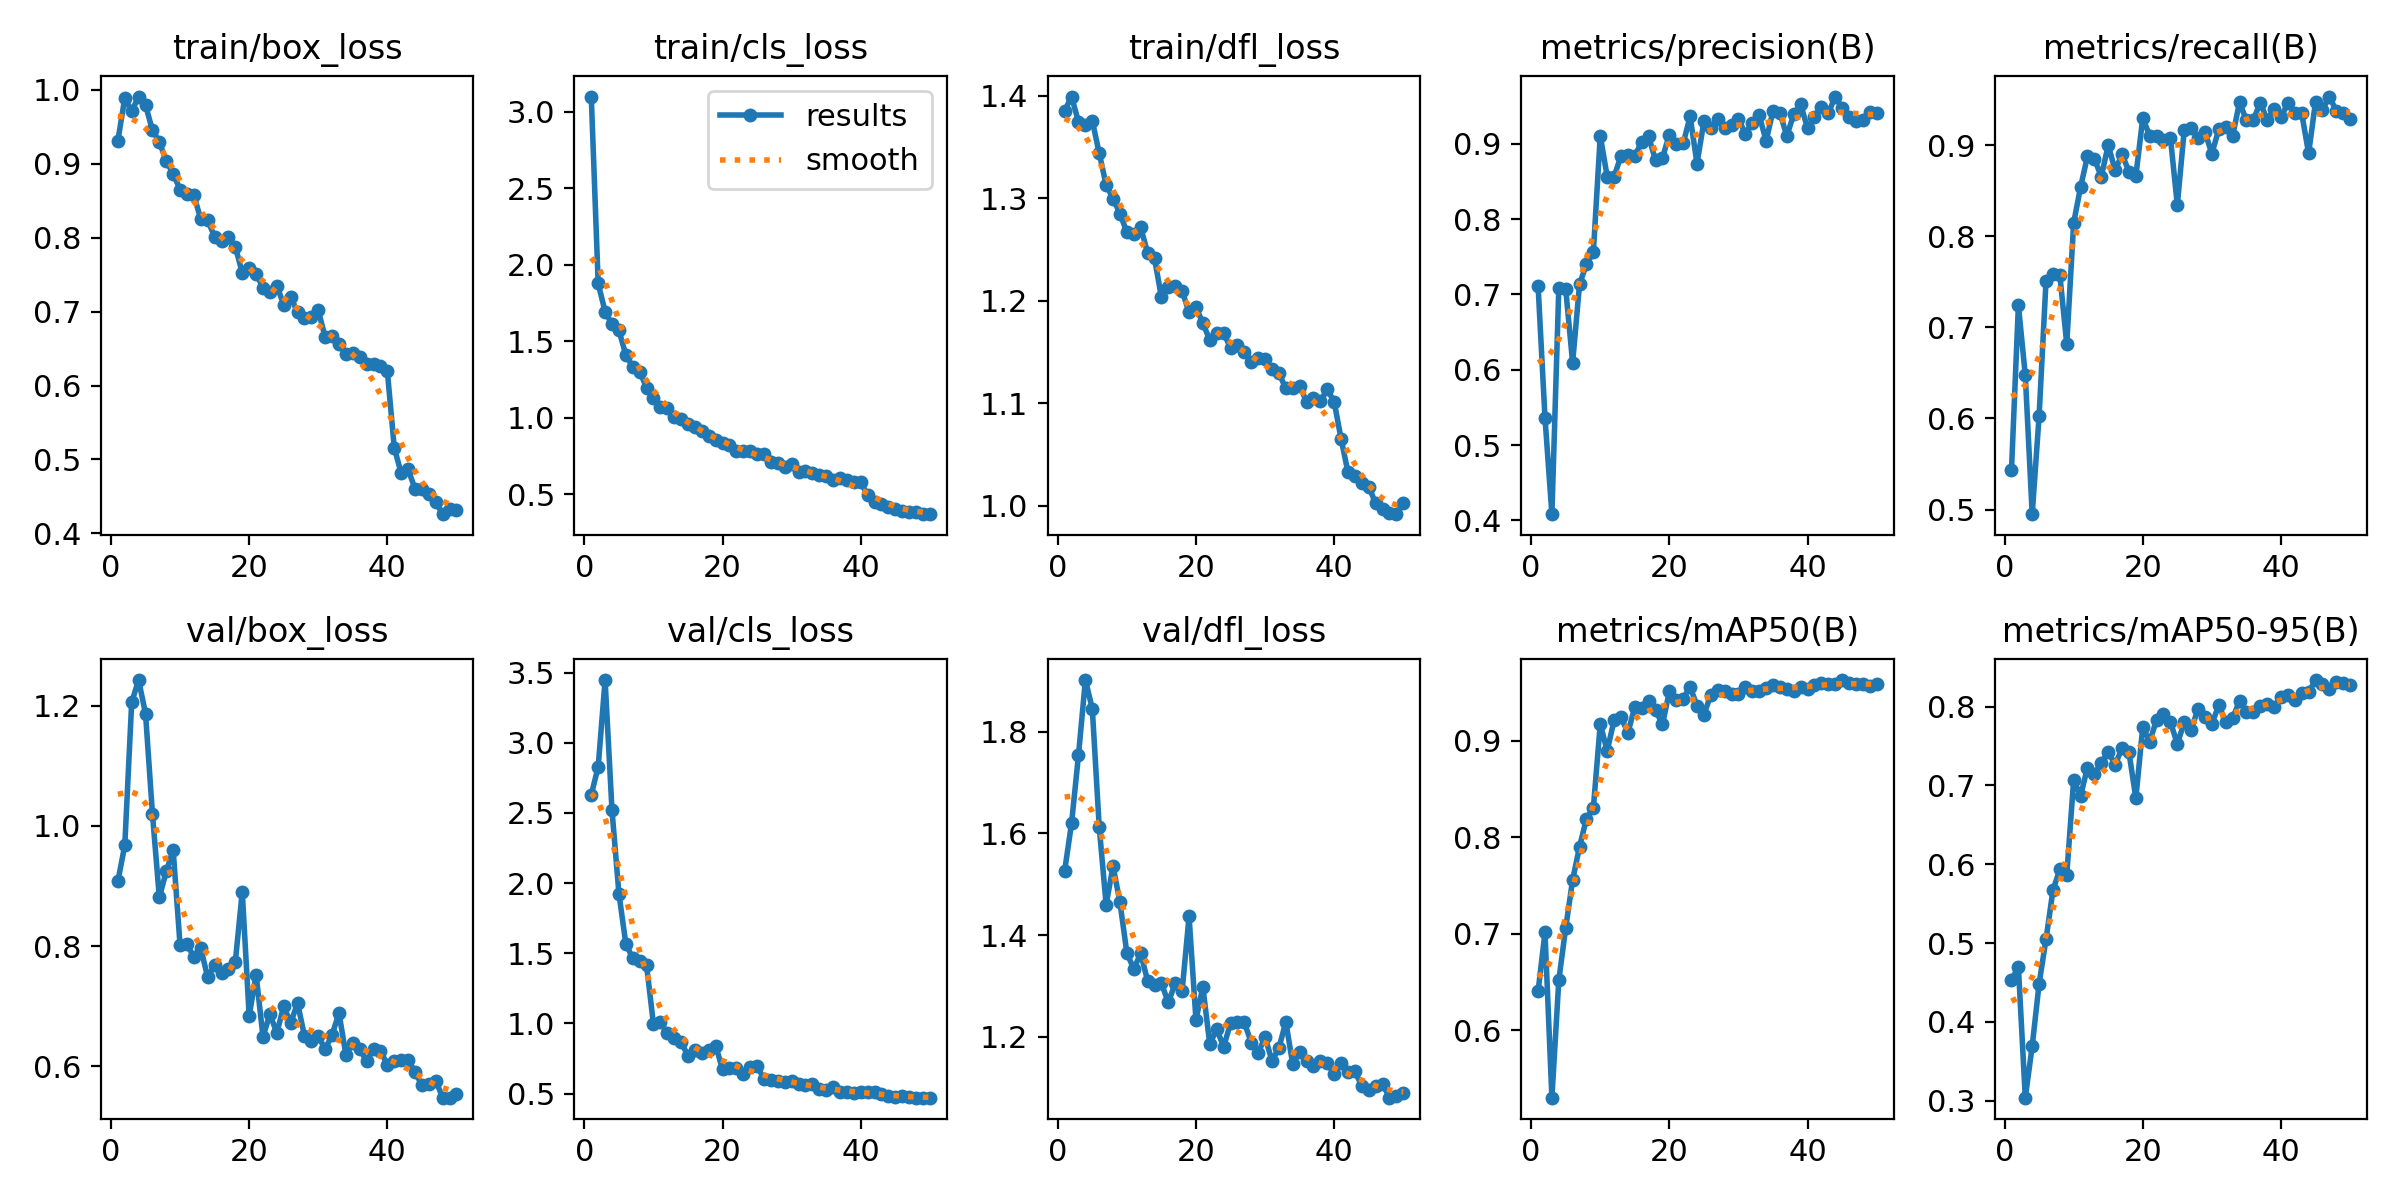

In [23]:
from IPython.display import Image, display

display(Image("/content/runs/household_objects-2/results.png"))

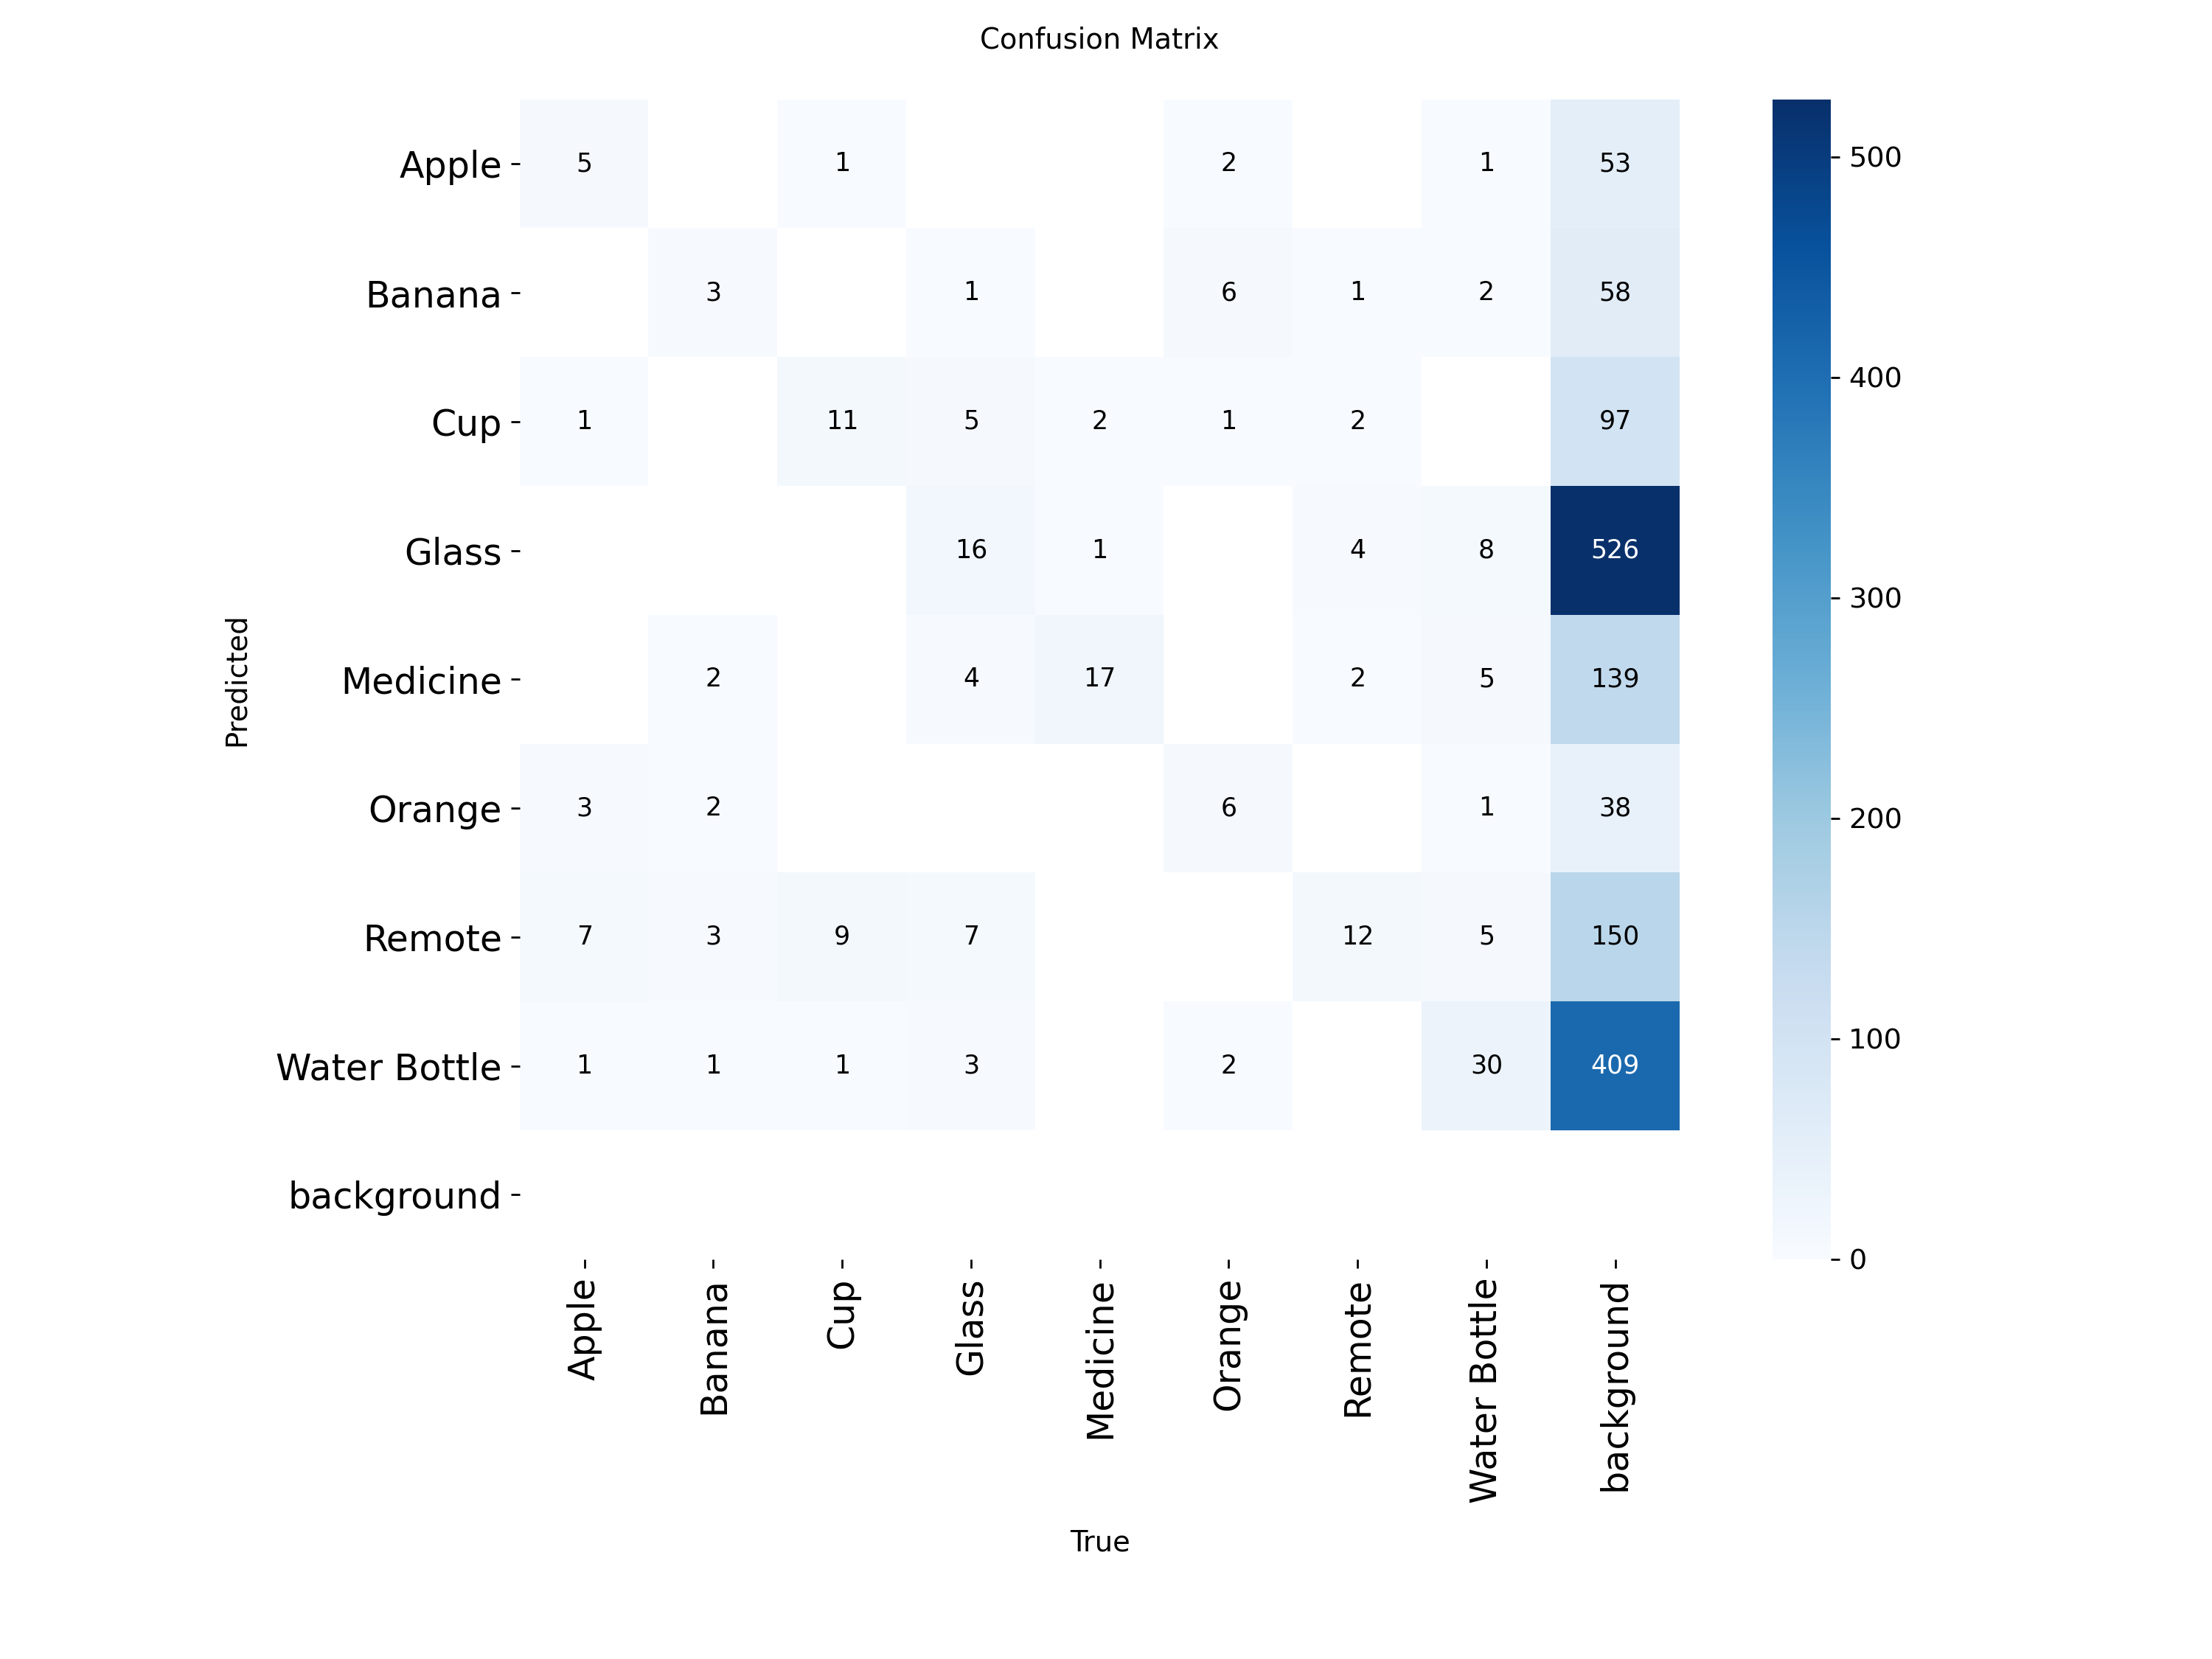

In [24]:
display(Image("/content/runs/household_objects-2/confusion_matrix.png"))

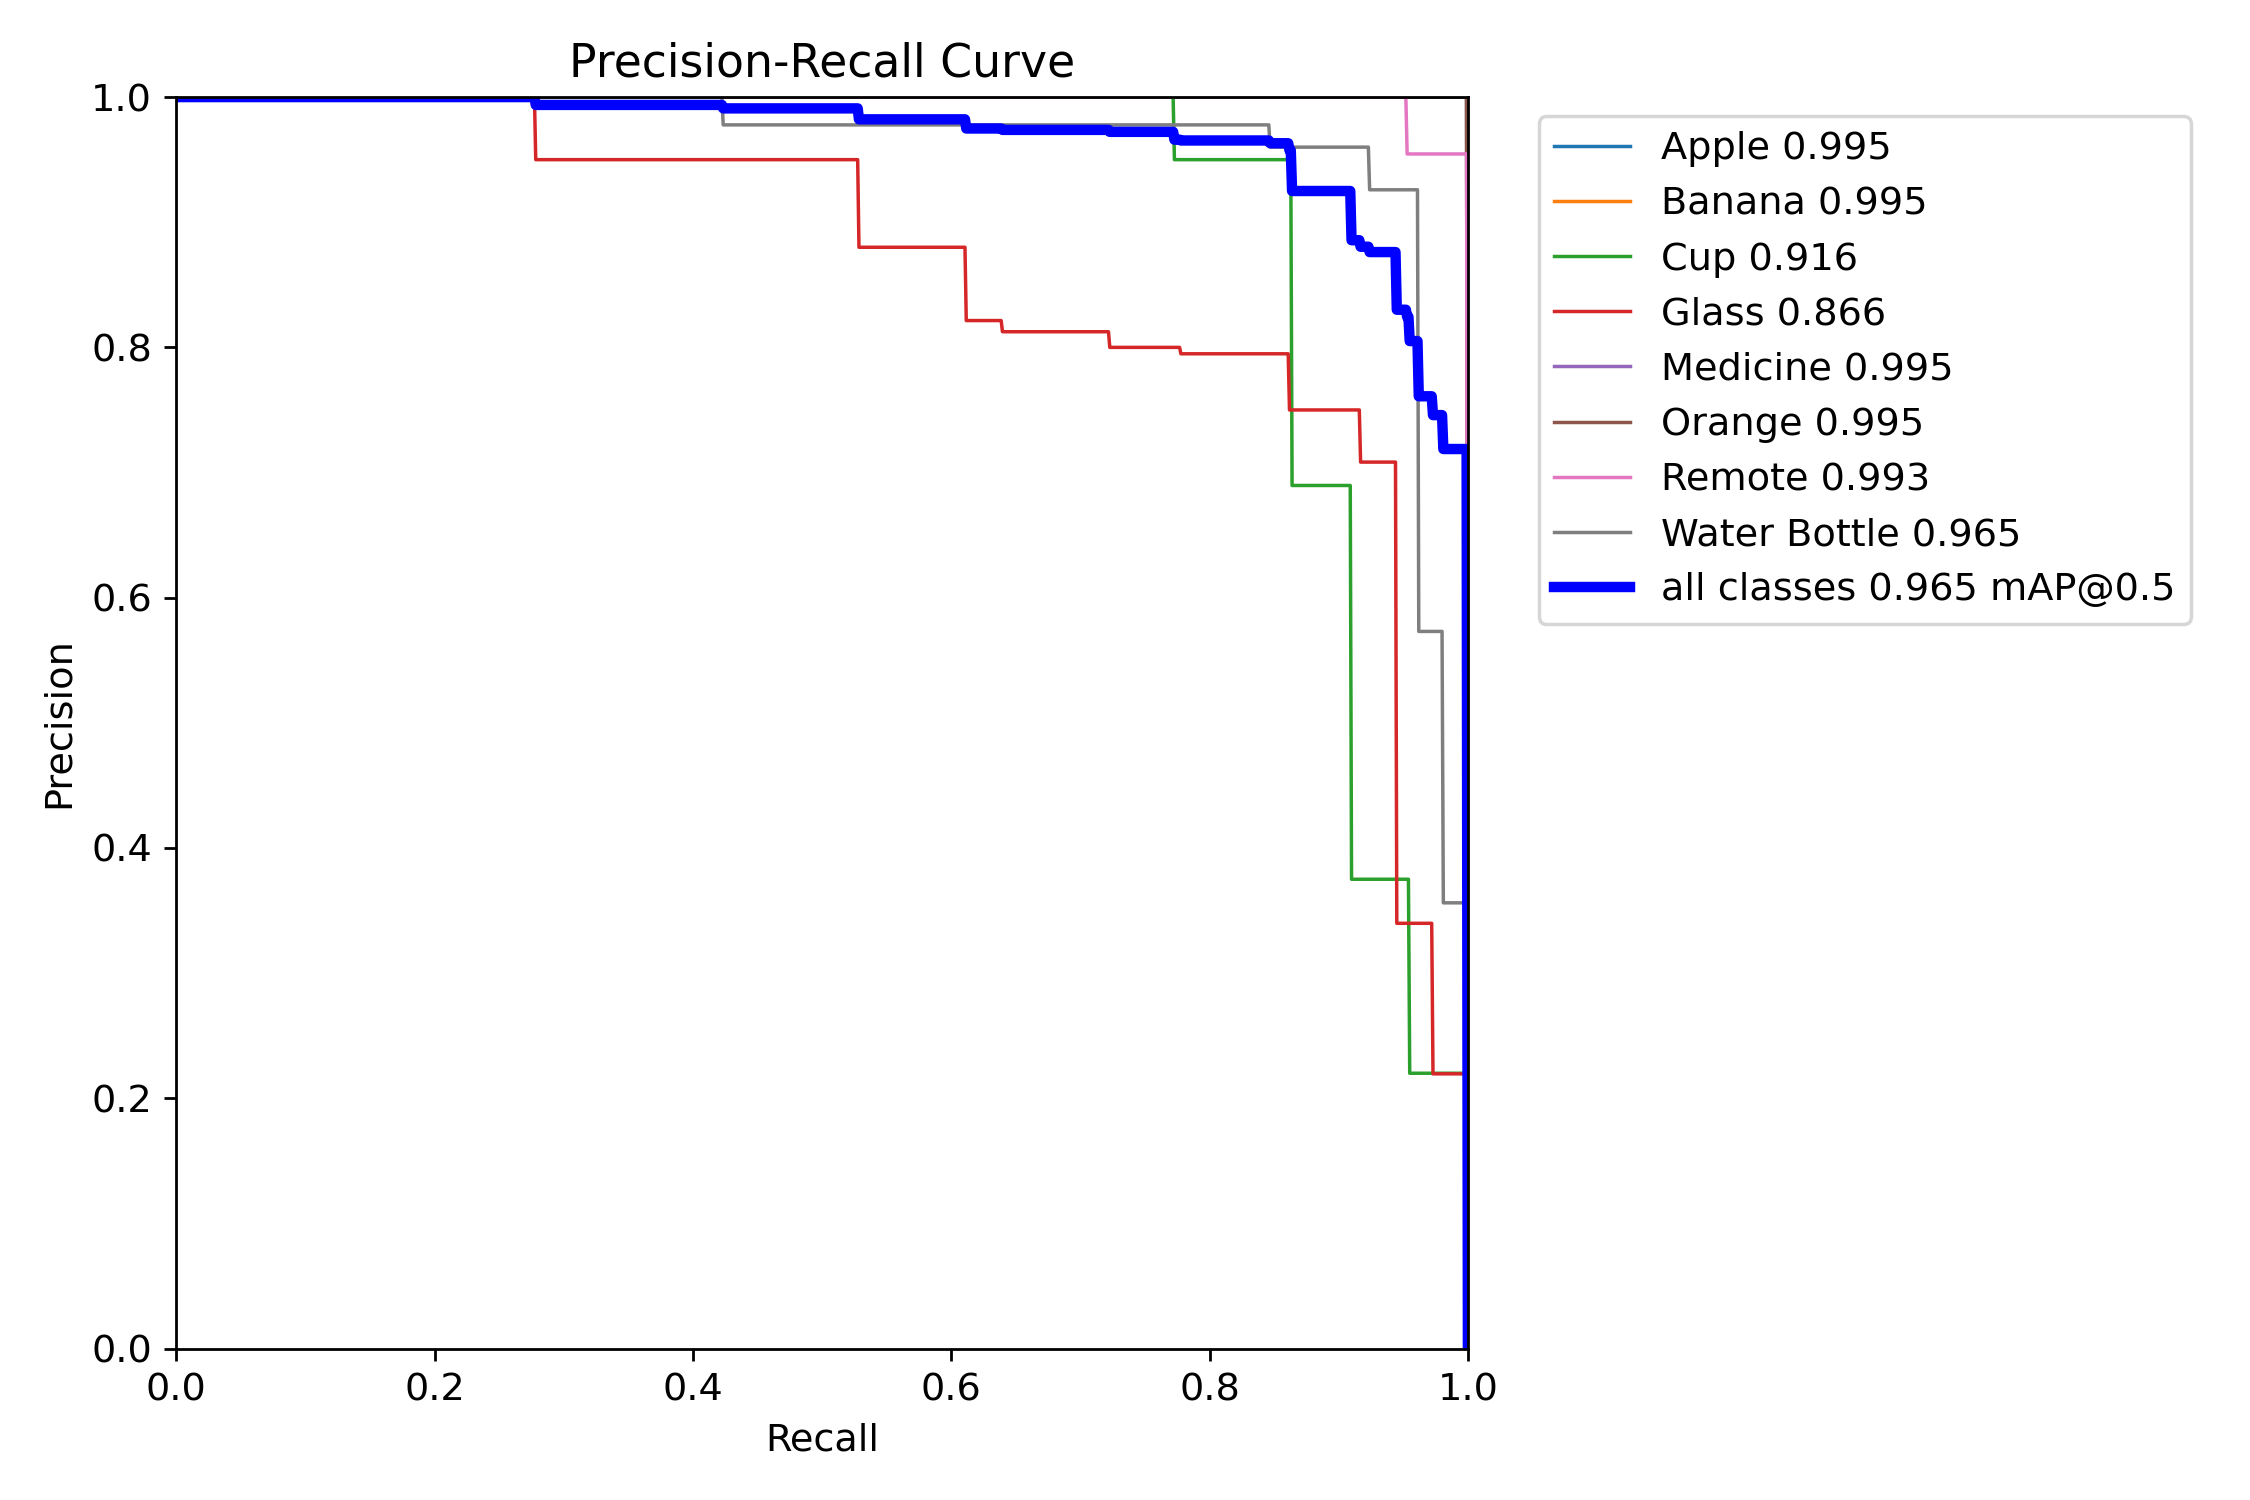

In [25]:
display(Image("/content/runs/household_objects-2/BoxPR_curve.png"))

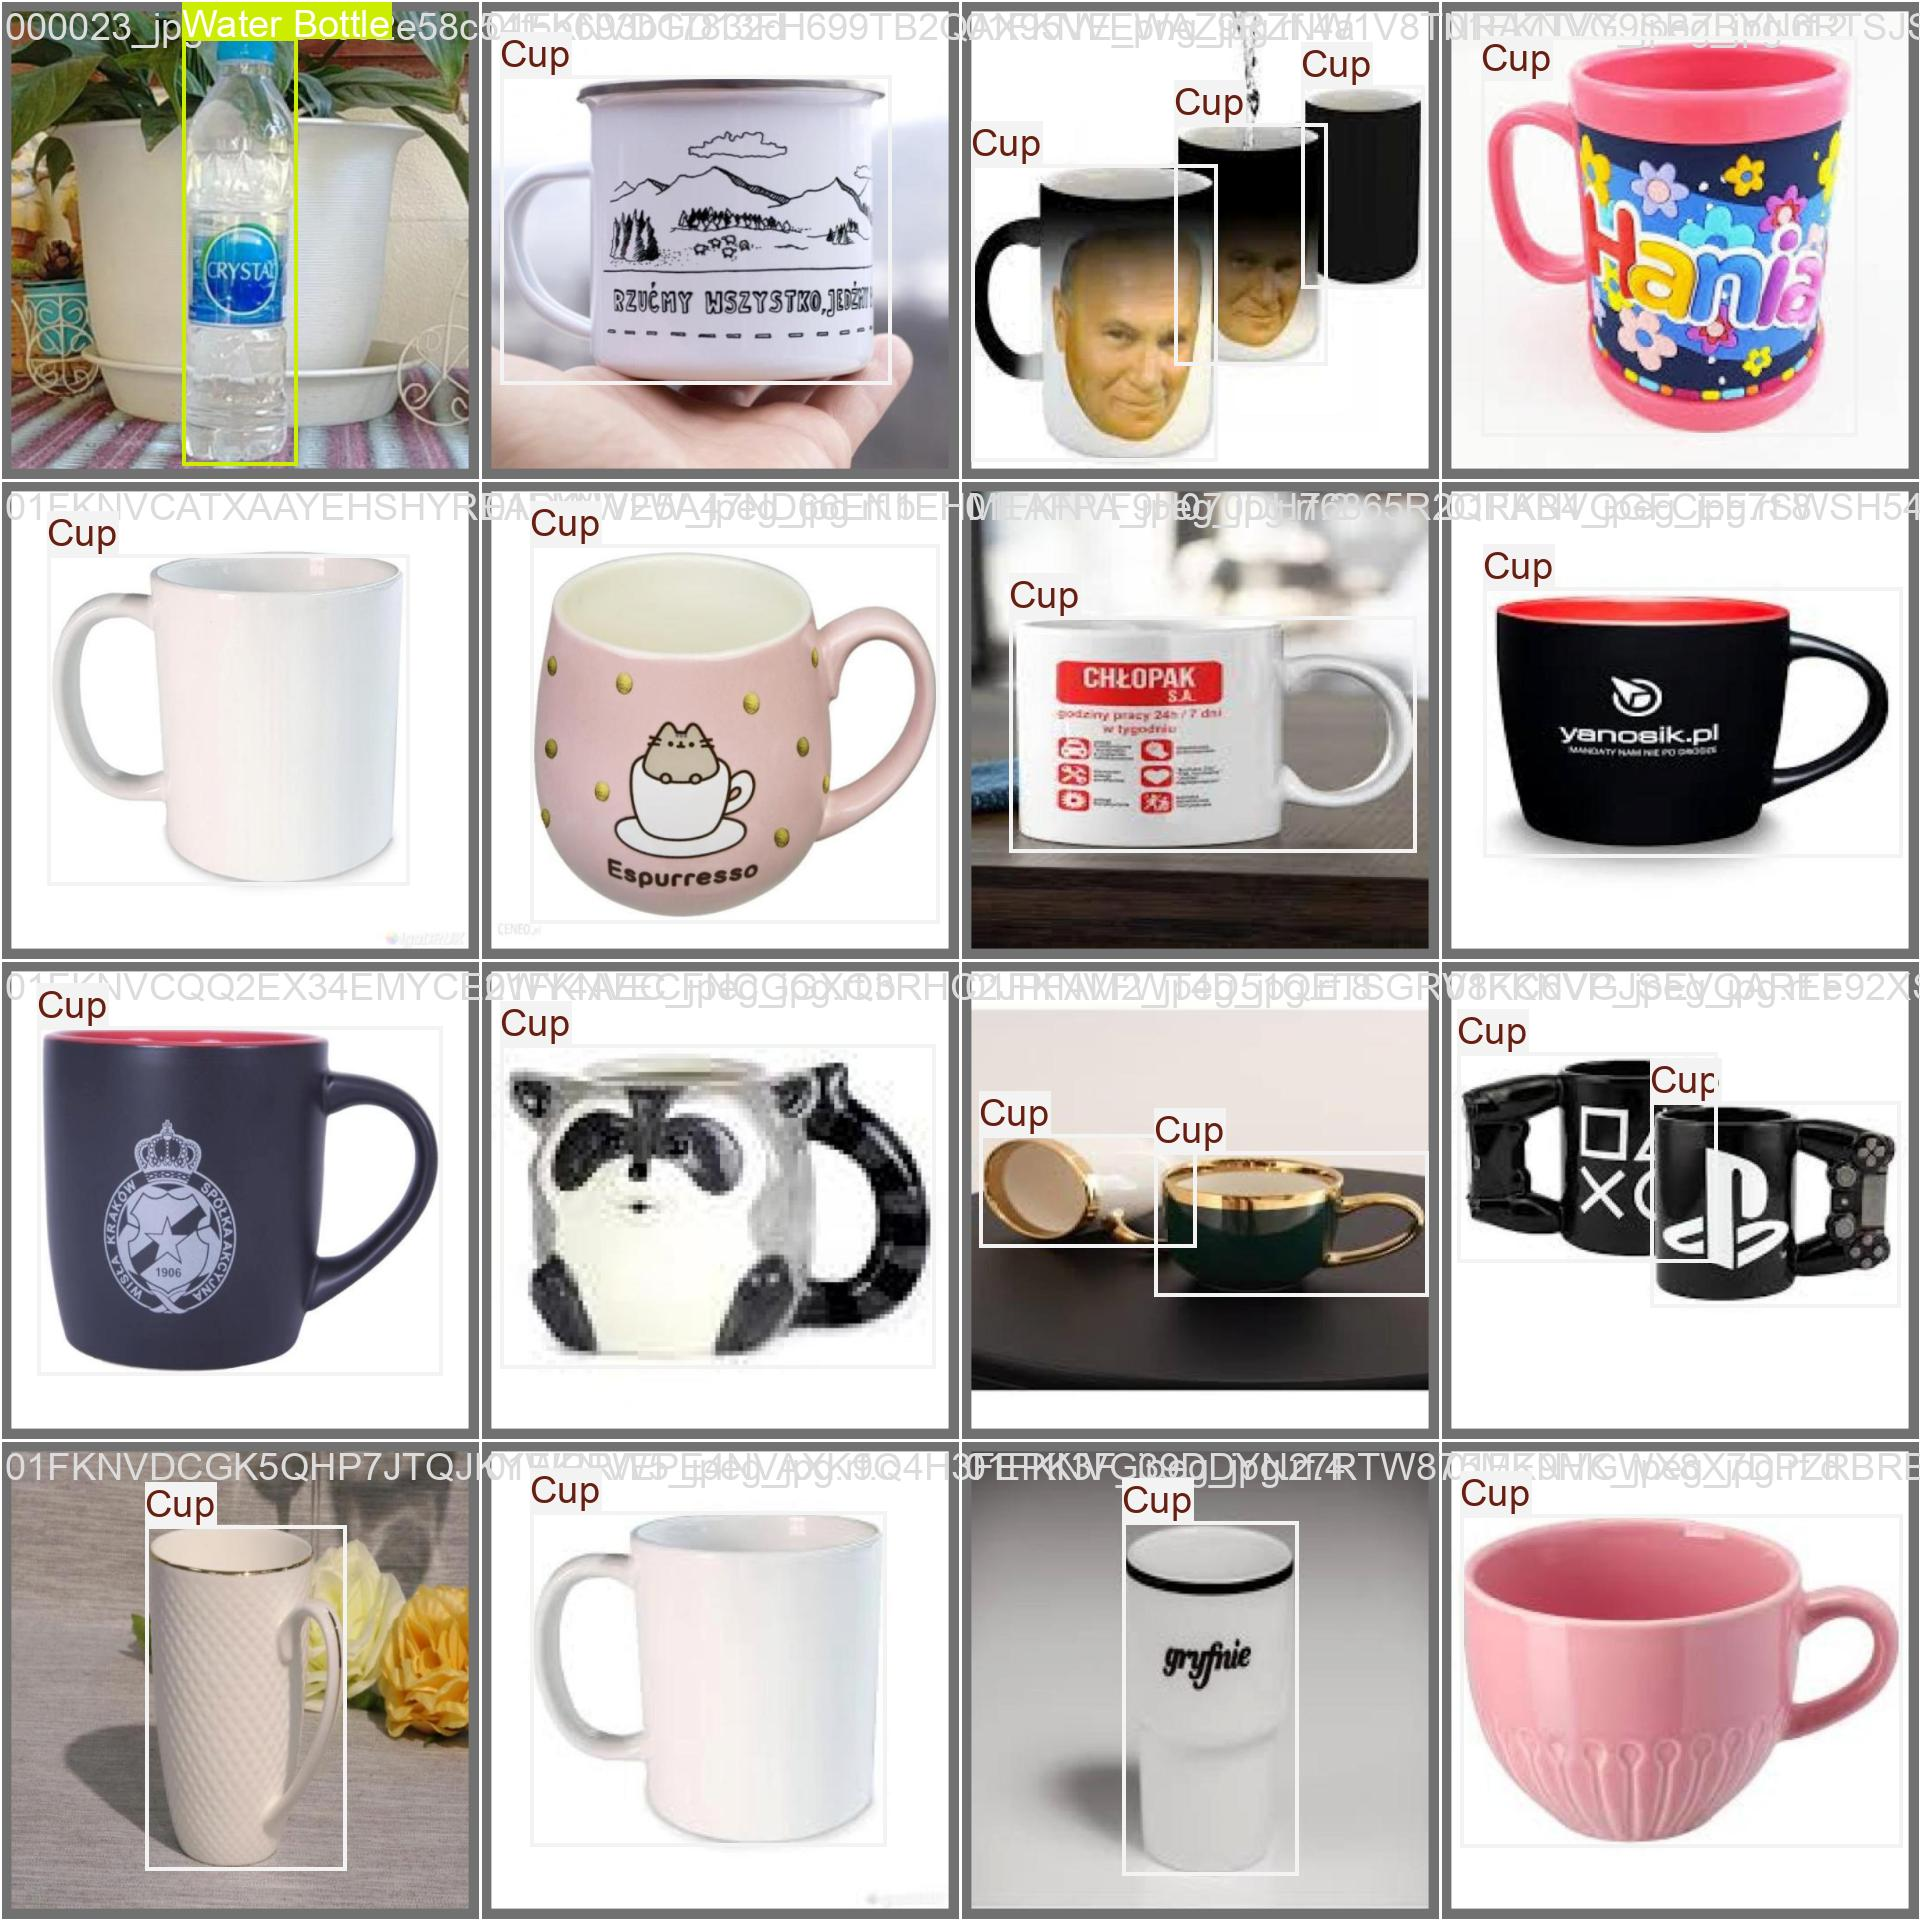

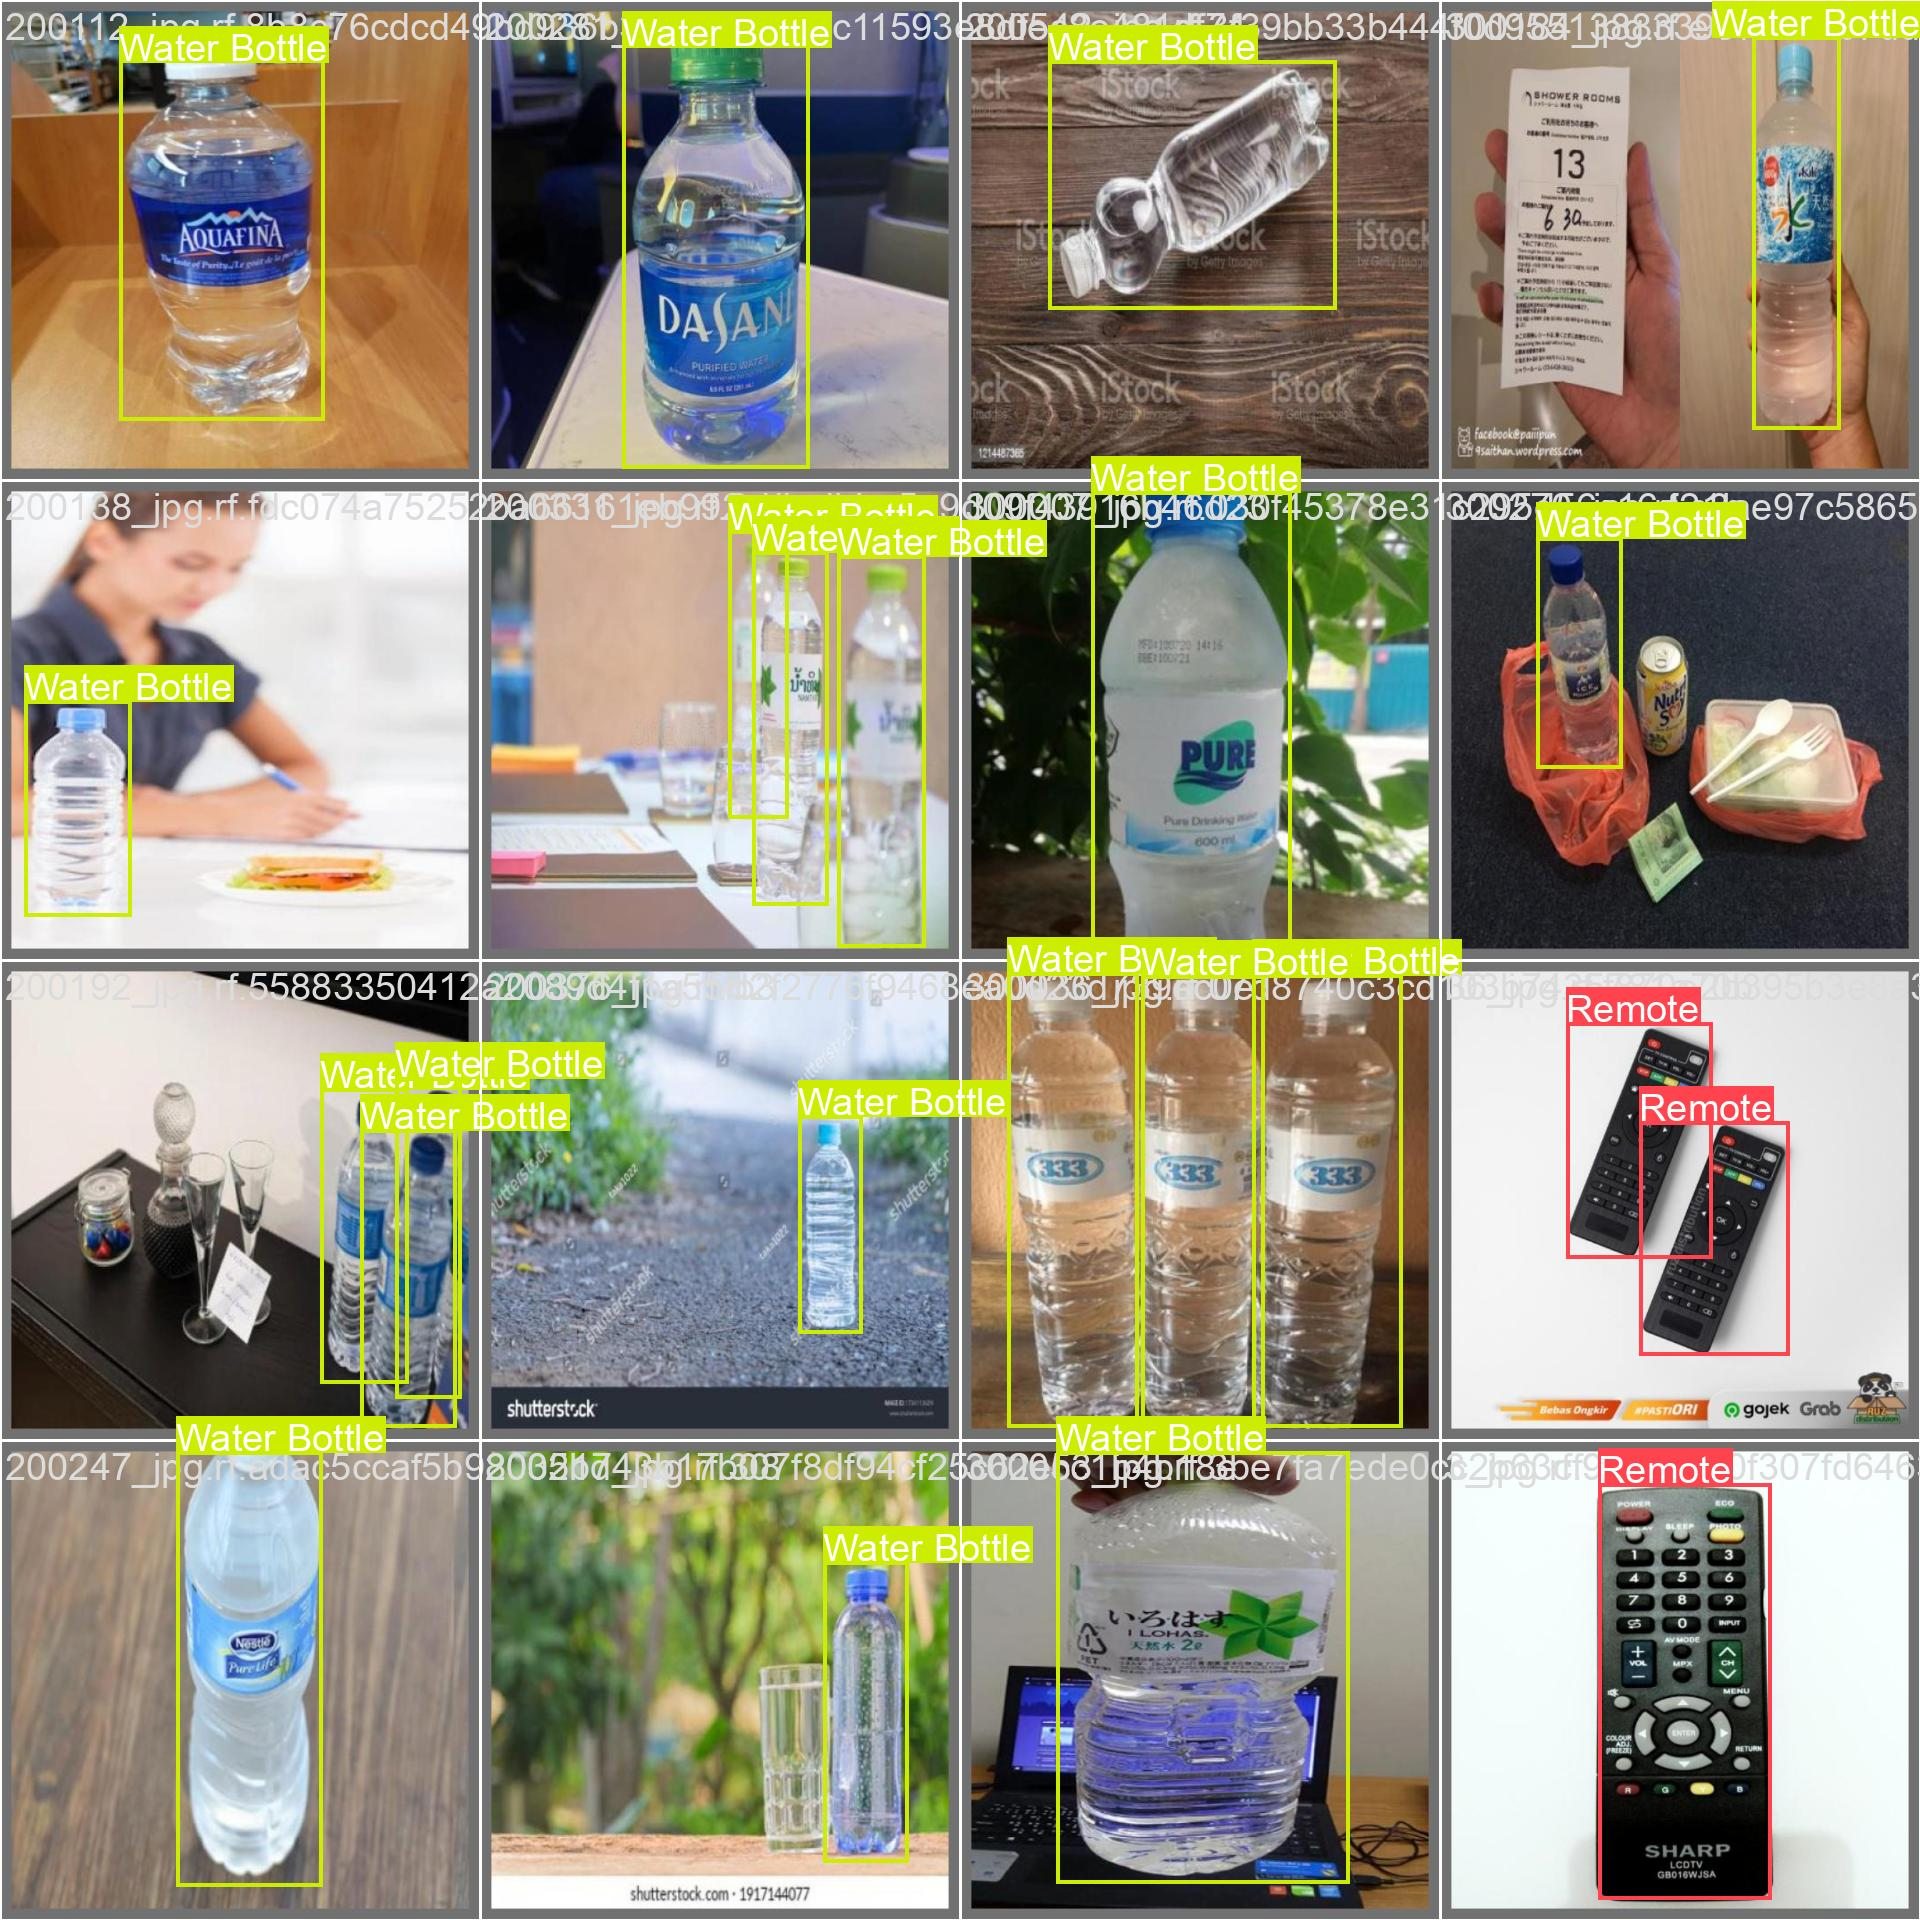

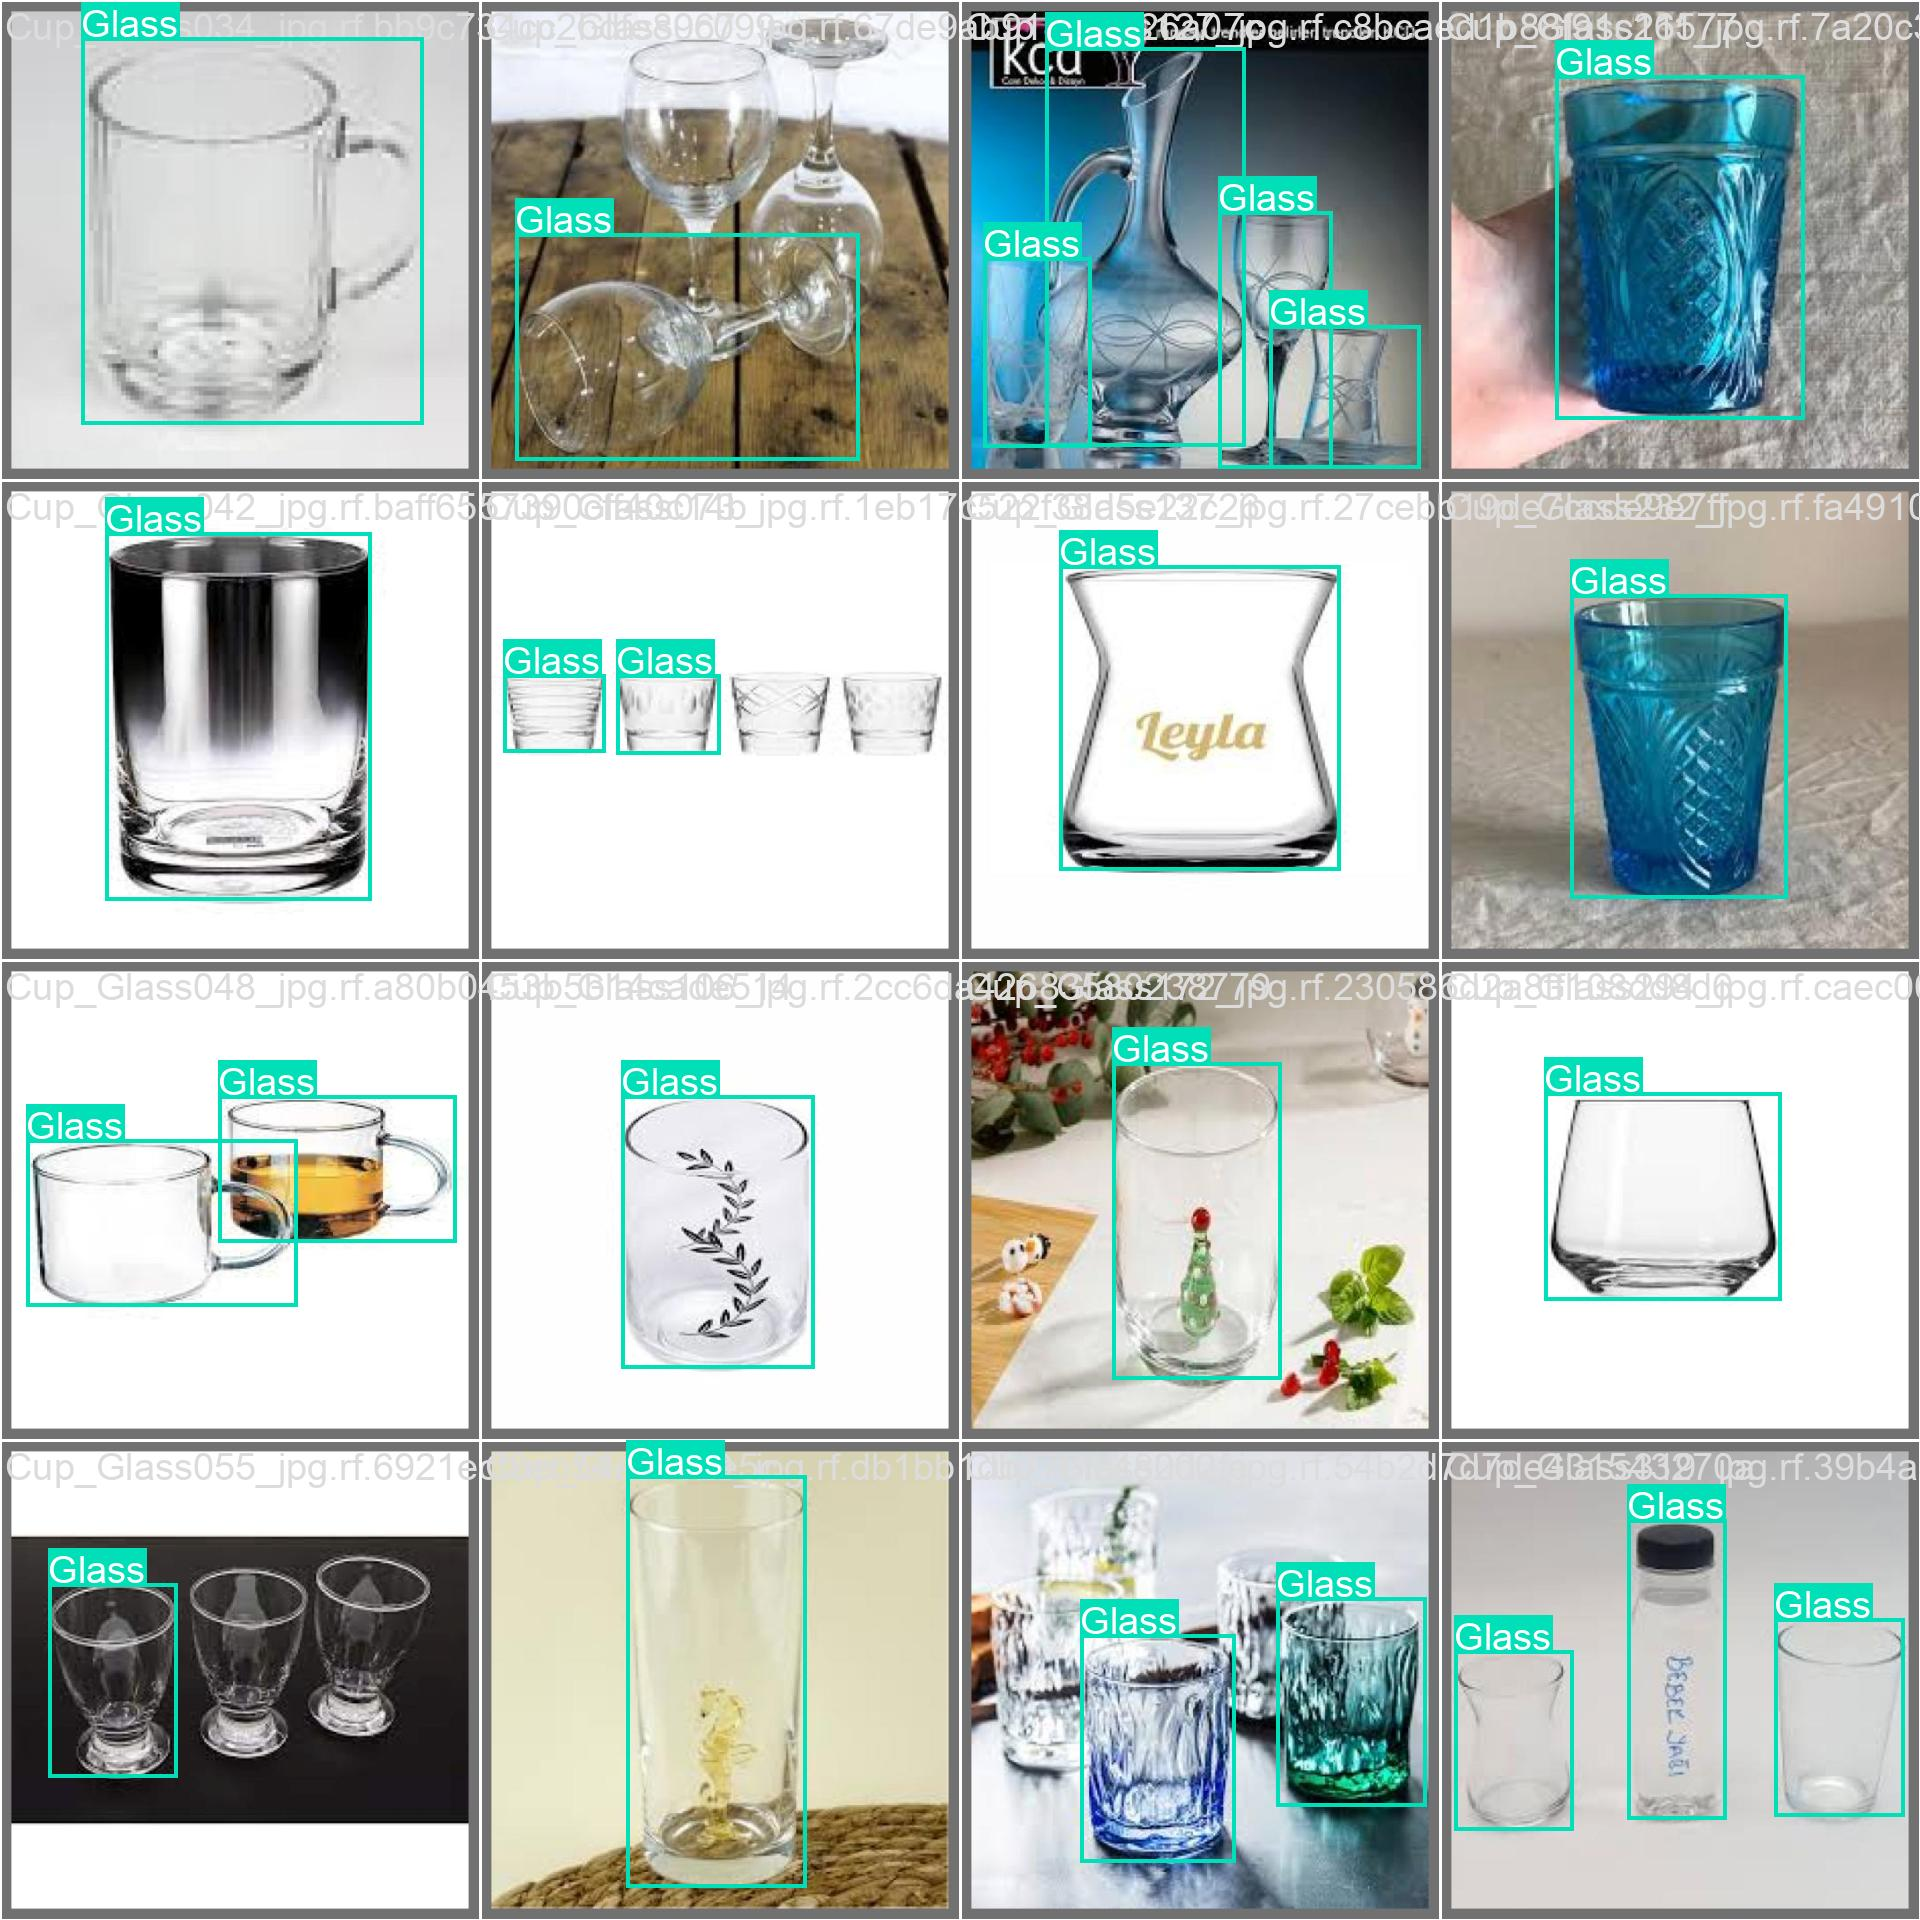

In [28]:
display(Image("/content/runs/household_objects-2/val_batch0_labels.jpg"))
display(Image("/content/runs/household_objects-2/val_batch1_labels.jpg"))
display(Image("/content/runs/household_objects-2/val_batch2_labels.jpg"))

In [29]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/household_objects-2/weights/best.pt")

## 📌 Model Evaluation

The custom YOLOv8n detector was trained on a household object dataset containing **8 object classes** and evaluated on **181 validation images**.

### Overall Performance

- Precision: **94.1%**
- Recall: **94.8%**
- mAP@50: **96.5%**
- mAP@50-95: **83.9%**

The model achieved high detection accuracy across most object categories, particularly **Apple, Banana, Medicine, Orange, and Remote**, all of which obtained mAP@50 values above 99%.

The comparatively lower performance for the **Glass** class is likely due to its transparent appearance and reflections, which make detection more challenging. Similarly, the **Cup** class includes variations with and without handles, introducing greater visual diversity.